# Down Syndrome Model Selection

### Common Imports

In [11]:
# suppress warnings
import warnings

warnings.filterwarnings("ignore")

In [12]:
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from keras.models import Sequential
from keras.layers import Dense

from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

### Load Data

In [13]:
df = pkl.load(open("../../../data/processed/down_syndrome/cleaned_df.pkl", "rb"))

### Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["target"]), df["target"], test_size=0.2, random_state=14
)

Because our data is highly imbalanced, we'll use SMOTE to oversample.

In [15]:
sm = SMOTE(sampling_strategy="auto", random_state=14)
X_train, y_train = sm.fit_resample(X_train, y_train)

### Data Transformation

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["mothers_single_year_age", "fathers_combined_age"])
    ]
)

In [17]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

### Logistic Regression Model

In [18]:
log_reg = LogisticRegression(random_state=14)

log_reg.fit(X_train_prepared, y_train)

pred_log_reg = log_reg.predict(X_test_prepared)

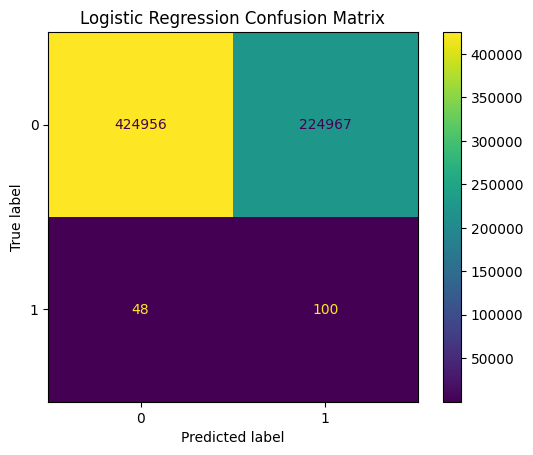

In [19]:
cm_log_reg = confusion_matrix(y_test, pred_log_reg)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg)
disp_log_reg.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [20]:
log_reg_f1_score = f1_score(y_test, pred_log_reg)
print(f"Logistic Regression F1 Score: {log_reg_f1_score:.4f}")

Logistic Regression F1 Score: 0.0009


### Random Forest Classifier

In [22]:
rfc = RandomForestClassifier(random_state=14, n_estimators=10, max_depth=5)

rfc.fit(X_train_prepared, y_train)

pred_rfc = rfc.predict(X_test_prepared)

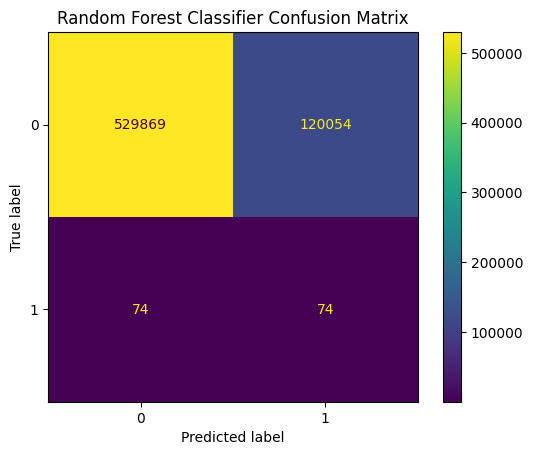

In [23]:
cm_rfc = confusion_matrix(y_test, pred_rfc)
disp_rfc = ConfusionMatrixDisplay(confusion_matrix=cm_rfc)
disp_rfc.plot()
plt.title("Random Forest Classifier Confusion Matrix")
plt.show()

In [24]:
rfc_f1_score = f1_score(y_test, pred_rfc)
print(f"Random Forest Classifier F1 Score: {rfc_f1_score:.4f}")

Random Forest Classifier F1 Score: 0.0012


### Neural Network

In [25]:
nn = Sequential()
nn.add(Dense(16, activation="relu", input_shape=(X_train_prepared.shape[1],)))
nn.add(Dense(8, activation="relu"))
nn.add(Dense(1, activation="sigmoid"))

nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

nn.fit(X_train_prepared, y_train, epochs=10, batch_size=32, verbose=0)

nn_preds = (nn.predict(X_test_prepared) > 0.5).astype(int)

E0000 00:00:1778178410.651220   70192 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778178410.656428   71486 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778178410.687711   70192 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


KeyboardInterrupt: 

In [ ]:
nn_cm = confusion_matrix(y_test, nn_preds)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=nn_cm)
disp_nn.plot()
plt.title("Neural Network Confusion Matrix")
plt.show()

In [ ]:
nn_f1_score = f1_score(y_test, (nn.predict(X_test_prepared) > 0.5).astype(int))
print(f"Neural Network F1 Score: {nn_f1_score:.4f}")